100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:10<00:00, 922kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 124kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:04<00:00, 374kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.97MB/s]


Epoch [1/20], Loss: 0.119222
Epoch [2/20], Loss: 0.112007
Epoch [3/20], Loss: 0.112000
Epoch [4/20], Loss: 0.112001
Epoch [5/20], Loss: 0.112002
Epoch [6/20], Loss: 0.112000
Epoch [7/20], Loss: 0.111999
Epoch [8/20], Loss: 0.112001
Epoch [9/20], Loss: 0.112004
Epoch [10/20], Loss: 0.111998
Epoch [11/20], Loss: 0.112001
Epoch [12/20], Loss: 0.112003
Epoch [13/20], Loss: 0.112004
Epoch [14/20], Loss: 0.112003
Epoch [15/20], Loss: 0.112003
Epoch [16/20], Loss: 0.112003
Epoch [17/20], Loss: 0.111999
Epoch [18/20], Loss: 0.112004
Epoch [19/20], Loss: 0.111998
Epoch [20/20], Loss: 0.112007


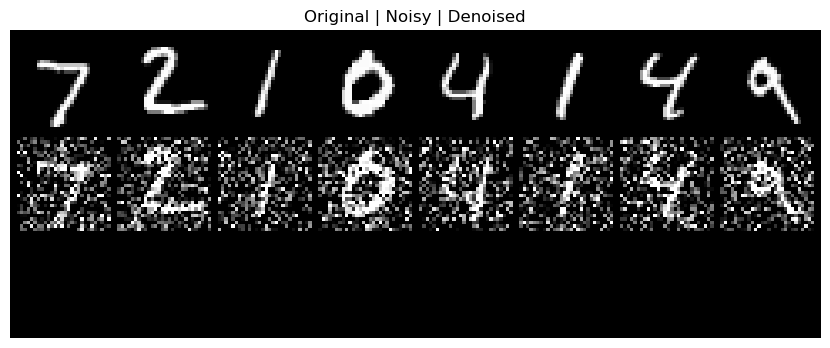

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.MNIST(root='./data_mnist', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data_mnist', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
class DenoiseAE(nn.Module):
    def __init__(self):
        super(DenoiseAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0,1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenoiseAE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def add_noise(img, noise_factor=0.5):
    noise = torch.randn_like(img) * noise_factor
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, 0.0, 1.0)
    return noisy_img


n_epochs = 20

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for i, (img, _) in enumerate(train_loader):
        img = img.to(device)
        noisy_img = add_noise(img, noise_factor=0.5)

        optimizer.zero_grad()
        output = model(noisy_img)
        loss = criterion(output, img)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.6f}")


model.eval()
data_iter = iter(test_loader)
test_img, _ = next(data_iter)
test_img = test_img.to(device)
noisy_test_img = add_noise(test_img, noise_factor=0.5)

with torch.no_grad():
    denoised_output = model(noisy_test_img)


n_show = 8
show_img = torch.cat((test_img[:n_show], noisy_test_img[:n_show], denoised_output[:n_show]), dim=0)
show_img = torch.clamp(show_img, 0.0, 1.0)

grid_img = vutils.make_grid(show_img, nrow=n_show, padding=2)

plt.figure(figsize=(12, 4))
plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.title("Original | Noisy | Denoised")
plt.axis('off')
plt.show()
